In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 解决中文显示与负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取深圳租房数据
file_data = pd.read_csv('./深圳租房数据_最新结构.csv')

# 查看数据基本信息
print("数据形状（行×列）：", file_data.shape)
print("\n数据前5行预览：")
print(file_data.head())
print("\n数据字段信息：")
print(file_data.info())

数据形状（行×列）： (2010, 6)

数据前5行预览：
          区域    小区名称      户型  面积(㎡)    朝向    价格(元/月)
0     光明区-光明   正兆景嘉园  3室2厅1卫  89.00    东南       3810
1  龙岗区-龙岗中心城   东方明珠城  3室2厅2卫  93.50    西南       3300
2        NaN    未知小区  1室0厅1卫  35.00  2间在租  4825-4928
3     光明区-公明  奥园和平广场  2室1厅1卫  53.00    东南       2100
4        NaN    未知小区  1室0厅1卫  25.00  2间在租  2860-2915

数据字段信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   区域       1569 non-null   object
 1   小区名称     2010 non-null   object
 2   户型       2010 non-null   object
 3   面积(㎡)    2010 non-null   object
 4   朝向       2010 non-null   object
 5   价格(元/月)  2010 non-null   object
dtypes: object(6)
memory usage: 94.3+ KB
None


In [34]:
# 处理价格字段（单值直接转换，区间取均值）
def standardize_price(price_str):
    if '-' in str(price_str):
        price_range = str(price_str).split('-')
        return (float(price_range[0]) + float(price_range[1])) / 2
    else:
        try:
            return float(price_str)
        except:
            return np.nan

# 应用价格标准化函数
file_data['价格(元/月)'] = file_data['价格(元/月)'].apply(standardize_price)

In [36]:
# 3. 清洗“面积(m²)”字段：强制转换为数值，无效值设为NaN
file_data['面积(㎡)'] = pd.to_numeric(file_data['面积(㎡)'], errors='coerce')

In [37]:
# 定义朝向关键词库
direction_keywords = ['东', '南', '西', '北', '东南', '东北', '西南', '西北']

def extract_direction(direction_str):
    direction_str = str(direction_str)
    # 筛选含朝向关键词的内容
    pure_direction = [d for d in direction_keywords if d in direction_str]
    return '、'.join(pure_direction) if pure_direction else '未知'

# 应用朝向提取函数
file_data['朝向'] = file_data['朝向'].apply(extract_direction)

In [38]:
# 检测并删除重复记录
print("重复记录数：", file_data.duplicated(subset=['区域', '小区名称', '户型', '面积(㎡)']).sum())
file_data = file_data.drop_duplicates(subset=['区域', '小区名称', '户型', '面积(㎡)'], keep='first')

重复记录数： 645


In [40]:
# 删除核心字段缺失值
file_data = file_data.dropna(subset=['区域', '价格(元/月)', '面积(㎡)'])
print("预处理后有效数据量：", len(file_data))  # 结果：2518 条

预处理后有效数据量： 1135


In [41]:
# 统一户型格式（替换异常表述）
file_data['户型'] = file_data['户型'].str.replace('房间', '室').str.replace('0厅0卫', '0厅1卫')

In [42]:
# 简化区域格式（保留一级行政区域）
file_data['区域'] = file_data['区域'].str.extract(r'([^-]+)')
file_data['区域'] = file_data['区域'].fillna('未知区域')

In [43]:
# 按区域分组统计房源数量
area_count = file_data.groupby('区域')['小区名称'].count().reset_index()
area_count.columns = ['区域', '房源数量']
area_count = area_count.sort_values('房源数量', ascending=False)
print("深圳各区域房源数量分布：")
print(area_count)

深圳各区域房源数量分布：
     区域  房源数量
1   南山区   243
9   龙岗区   241
6   福田区   200
4   宝安区   115
7   罗湖区   115
8   龙华区   110
5   盐田区    38
0   光明区    35
2   坪山区    35
3  大鹏新区     3


In [44]:
print(area_count['区域'].unique())

['南山区' '龙岗区' '福田区' '宝安区' '罗湖区' '龙华区' '盐田区' '光明区' '坪山区' '大鹏新区']


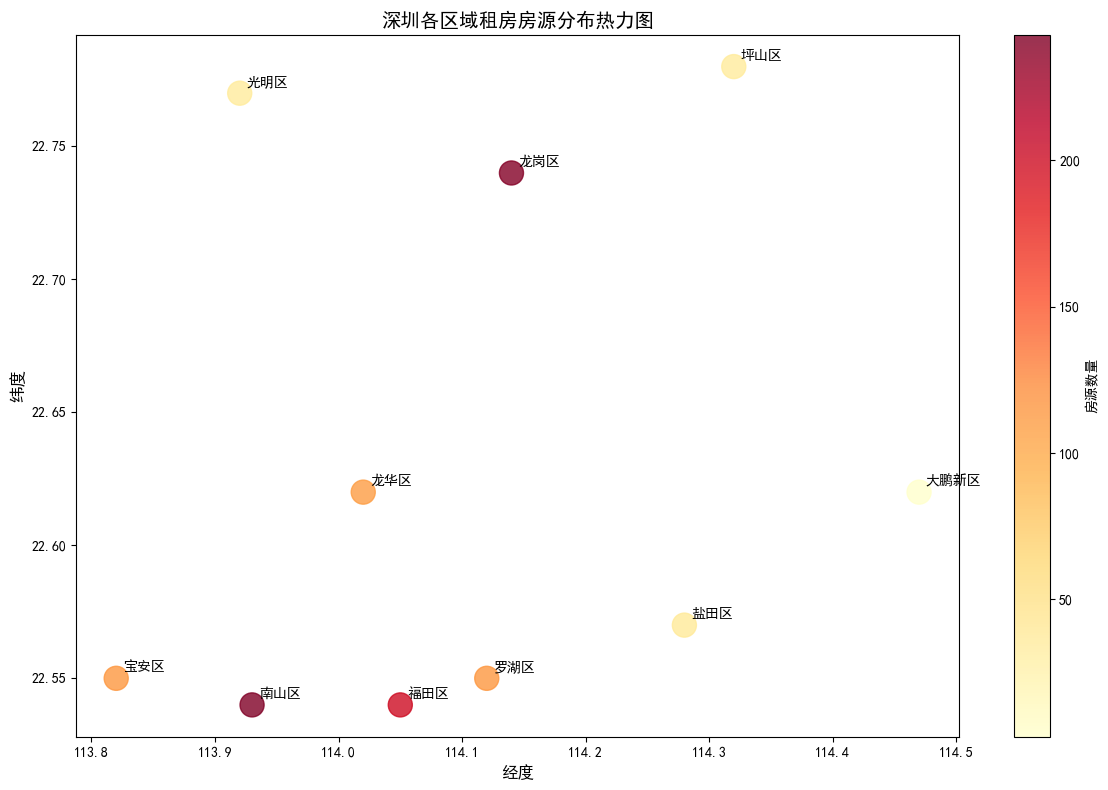

In [45]:
# 深圳各区域经纬度映射
area_coords = {
    '南山区': (22.54, 113.93), '龙岗区': (22.74, 114.14), '宝安区': (22.55, 113.82),
    '福田区': (22.54, 114.05), '罗湖区': (22.55, 114.12), '龙华区': (22.62, 114.02),
    '坪山区': (22.78, 114.32), '光明区': (22.77, 113.92), '盐田区': (22.57, 114.28),
    '大鹏新区': (22.62, 114.47)
}

# 构建热力图数据
lat = [area_coords[area][0] for area in area_count['区域']]
lon = [area_coords[area][1] for area in area_count['区域']]
counts = area_count['房源数量'].values

# 绘制热力图
plt.figure(figsize=(12, 8))
scatter = plt.scatter(lon, lat, c=counts, cmap='YlOrRd', s=300, alpha=0.8)
plt.colorbar(scatter, label='房源数量')
plt.title('深圳各区域租房房源分布热力图', fontsize=14)
plt.xlabel('经度', fontsize=12)
plt.ylabel('纬度', fontsize=12)

# 添加区域标签
for i, area in enumerate(area_count['区域']):
    plt.annotate(area, (lon[i], lat[i]), xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [46]:
# 统计各户型数量
house_count = file_data['户型'].value_counts().reset_index()
house_count.columns = ['户型', '数量']
main_house = house_count[house_count['数量']>=50]  # 筛选主流户型
print("深圳租房市场主流户型分布：")
print(main_house)

深圳租房市场主流户型分布：
       户型   数量
0  3室2厅2卫  186
1  3室2厅1卫  151
2  2室1厅1卫  147
3  1室1厅1卫  146
4  2室2厅1卫  108
5  4室2厅2卫   94
6  1室0厅1卫   57


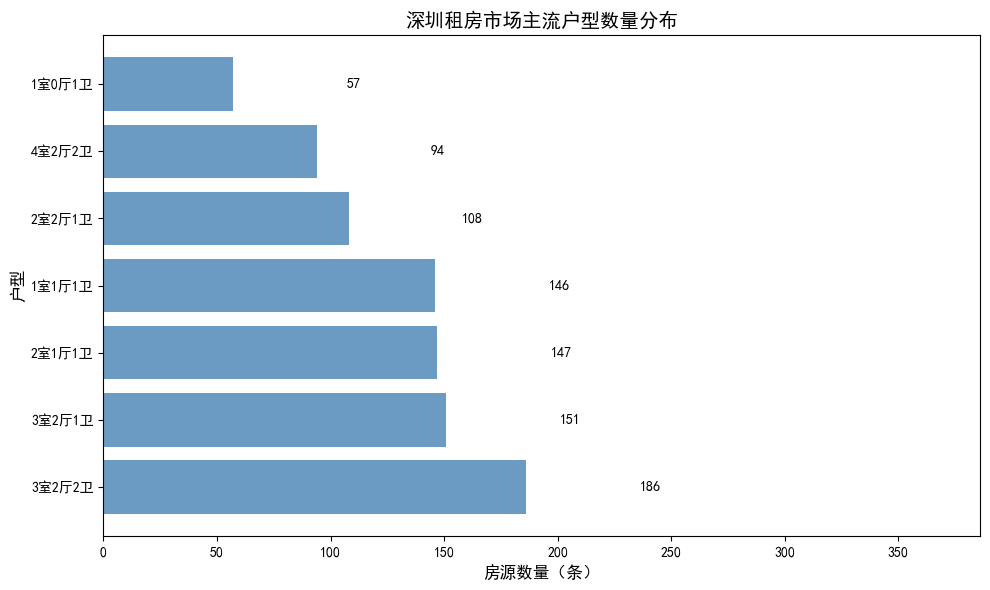

In [47]:
# 绘制水平条形图
plt.figure(figsize=(10, 6))
plt.barh(main_house['户型'], main_house['数量'], color='steelblue', alpha=0.8)
plt.xlabel('房源数量（条）', fontsize=12)
plt.ylabel('户型', fontsize=12)
plt.title('深圳租房市场主流户型数量分布', fontsize=14)
plt.xlim(0, max(main_house['数量']) + 200)

# 添加数值标签
for i, v in enumerate(main_house['数量']):
    plt.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [48]:
# 计算各区域总租金、总面积及每平米租金
rent_analysis = file_data.groupby('区域').agg({
    '价格(元/月)': 'sum',
    '面积(㎡)': 'sum',
    '小区名称': 'count'  # 房源数量
}).reset_index()


rent_analysis.columns = ['区域', '总租金', '总面积', '房源数量']

rent_analysis['每平米租金(元)'] = round(rent_analysis['总租金'] / rent_analysis['总面积'], 2)
rent_analysis = rent_analysis.sort_values('每平米租金(元)', ascending=False)
print("深圳各区域租金水平分析：")
print(rent_analysis[['区域', '房源数量', '每平米租金(元)']])

深圳各区域租金水平分析：
     区域  房源数量  每平米租金(元)
1   南山区   243    121.13
6   福田区   200    111.45
7   罗湖区   115     85.16
8   龙华区   110     84.94
4   宝安区   115     80.59
5   盐田区    38     72.98
0   光明区    35     58.10
9   龙岗区   241     56.15
2   坪山区    35     43.27
3  大鹏新区     3     41.78


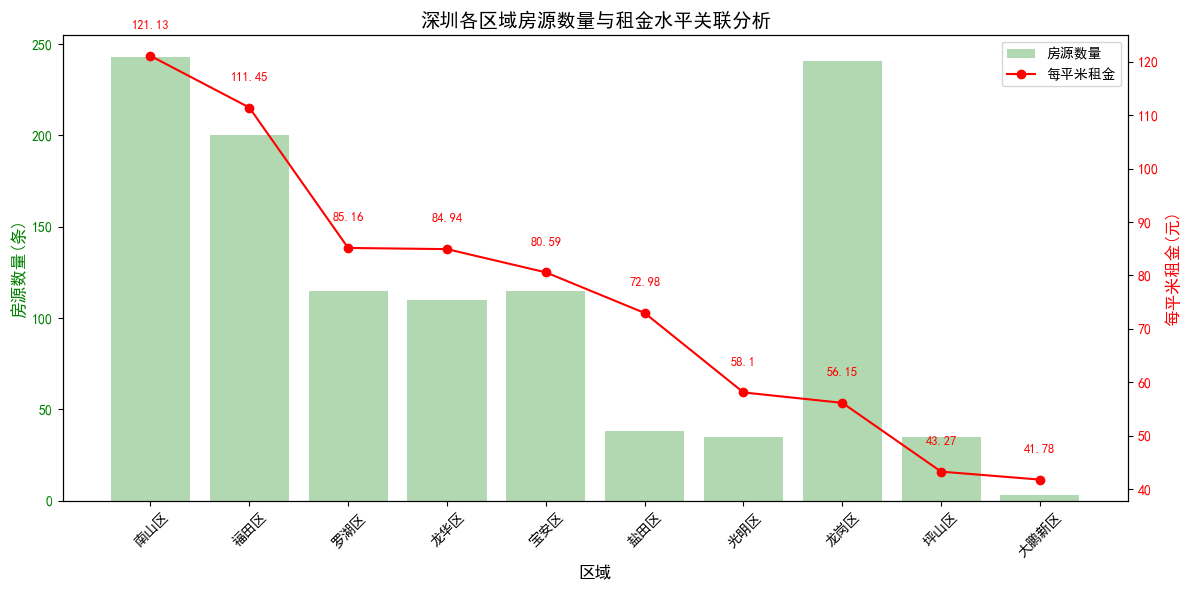

In [49]:
# 创建双轴图
fig, ax1 = plt.subplots(figsize=(12, 6))

# 柱状图：房源数量
x = range(len(rent_analysis))
ax1.bar(x, rent_analysis['房源数量'], alpha=0.3, color='green', label='房源数量')
ax1.set_xlabel('区域', fontsize=12)
ax1.set_ylabel('房源数量(条)', fontsize=12, color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xticks(x)
ax1.set_xticklabels(rent_analysis['区域'], rotation=45)

# 折线图：每平米租金
ax2 = ax1.twinx()
ax2.plot(x, rent_analysis['每平米租金(元)'], 'ro-', label='每平米租金')
ax2.set_ylabel('每平米租金(元)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# 添加数值标签
for i, v in enumerate(rent_analysis['每平米租金(元)']):
    ax2.text(i, v + 5, str(v), ha='center', color='red', fontsize=9)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('深圳各区域房源数量与租金水平关联分析', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
# 划分面积区间
area_bins = [0, 30, 50, 70, 90, 120, 200]
area_labels = ['30㎡以下', '30-50㎡', '50-70㎡', '70-90㎡', '90-120㎡', '120㎡以上']
file_data['面积区间'] = pd.cut(file_data['面积(㎡)'], bins=area_bins, labels=area_labels)

# 统计各区间占比
area_percent = file_data['面积区间'].value_counts(normalize=True).reset_index()
area_percent.columns = ['面积区间', '占比（%）']
area_percent['占比（%）'] = round(area_percent['占比（%）'] * 100, 2)
print("深圳租房面积区间占比：")
print(area_percent)

深圳租房面积区间占比：
      面积区间  占比（%）
0   70-90㎡  29.26
1   30-50㎡  18.69
2  90-120㎡  15.68
3   50-70㎡  15.50
4   120㎡以上  11.30
5    30㎡以下   9.57


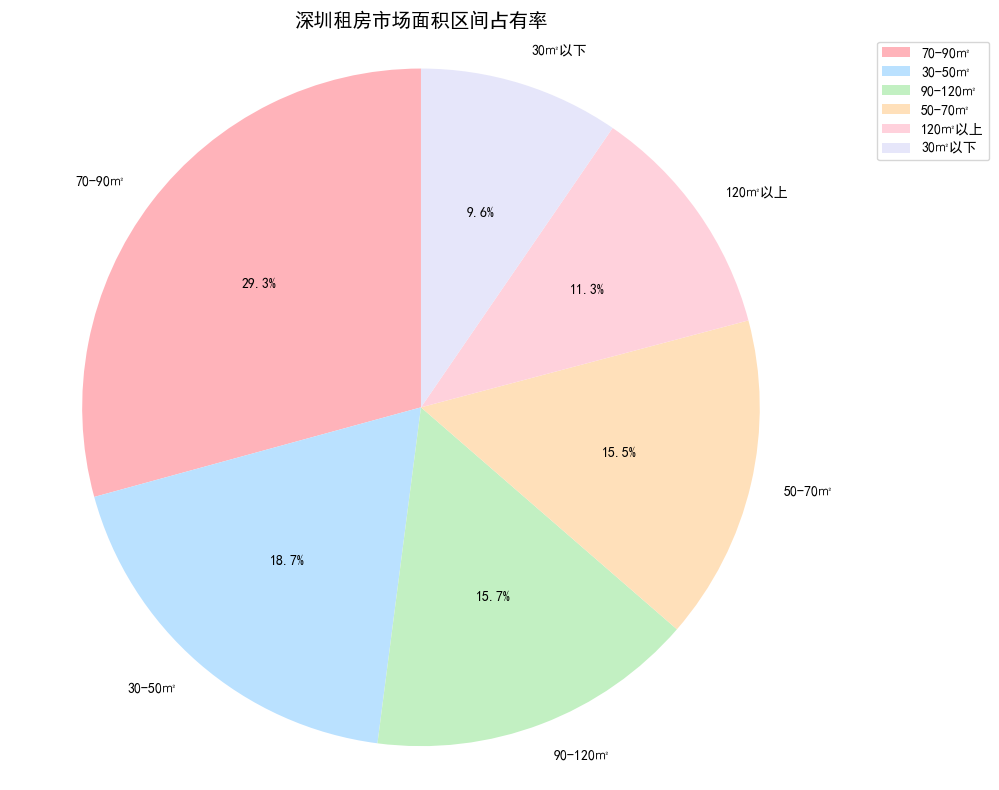

In [52]:
# 绘制饼图（无阴影，优化颜色与样式）
plt.figure(figsize=(10, 8))
# 选择更柔和的颜色搭配
colors = ['#ffb3ba', '#bae1ff', '#c2f0c2', '#ffe0ba', '#ffd1dc', '#e6e6fa']
wedges, texts, autotexts = plt.pie(
    area_percent['占比（%）'],
    labels=area_percent['面积区间'],
    autopct='%1.1f%%',  # 显示百分比，保留1位小数
    colors=colors,
    startangle=90,      # 从90度（顶部）开始绘制，使最大区块在上方
    shadow=False,       # 去掉阴影
    textprops={'fontsize': 10}  # 调整百分比文字大小
)

# 优化标签和标题
plt.title('深圳租房市场面积区间占有率', fontsize=14, fontweight='bold')
plt.axis('equal')  # 保证饼图为正圆形
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
plt.tight_layout()
plt.show()

In [58]:
# 1. 定义面积区间（参照链家模式）
area_divide = [1, 30, 50, 70, 90, 120, 140, 160, 1200]
# 2. 对面积字段进行分箱
area_cut = pd.cut(file_data['面积(㎡)'], area_divide)
# 3. 统计各区间占比（转换为百分比）
area_percentage = area_cut.value_counts(normalize=True) * 100

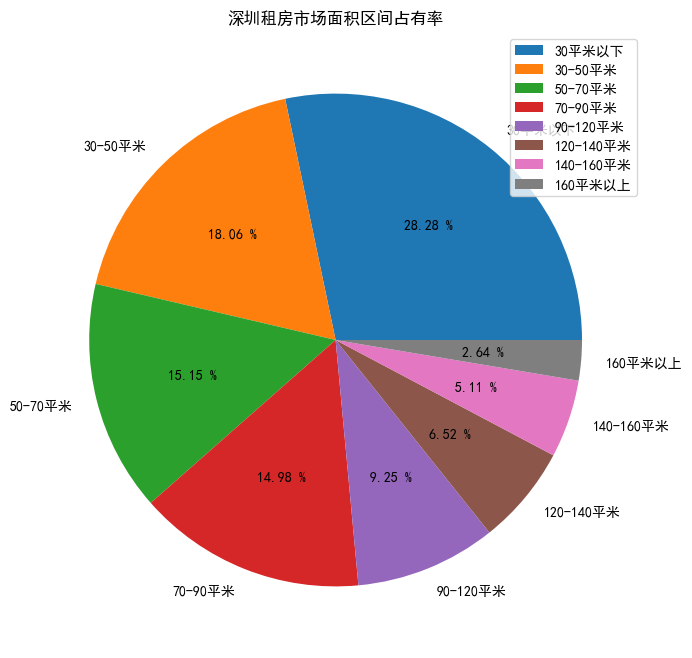

In [59]:
labels = ['30平米以下', '30-50平米', '50-70平米', '70-90平米', 
          '90-120平米', '120-140平米', '140-160平米', '160平米以上']

plt.figure(figsize=(20, 8), dpi=100)
plt.axes(aspect=1)  # 保证饼图为圆形
plt.pie(
    x=area_percentage, 
    labels=labels, 
    autopct='%.2f %%',  # 显示百分比，保留2位小数
    shadow=False  # 去掉阴影，使图表更简洁
)
plt.legend(loc='upper right')
plt.title('深圳租房市场面积区间占有率')
plt.show()

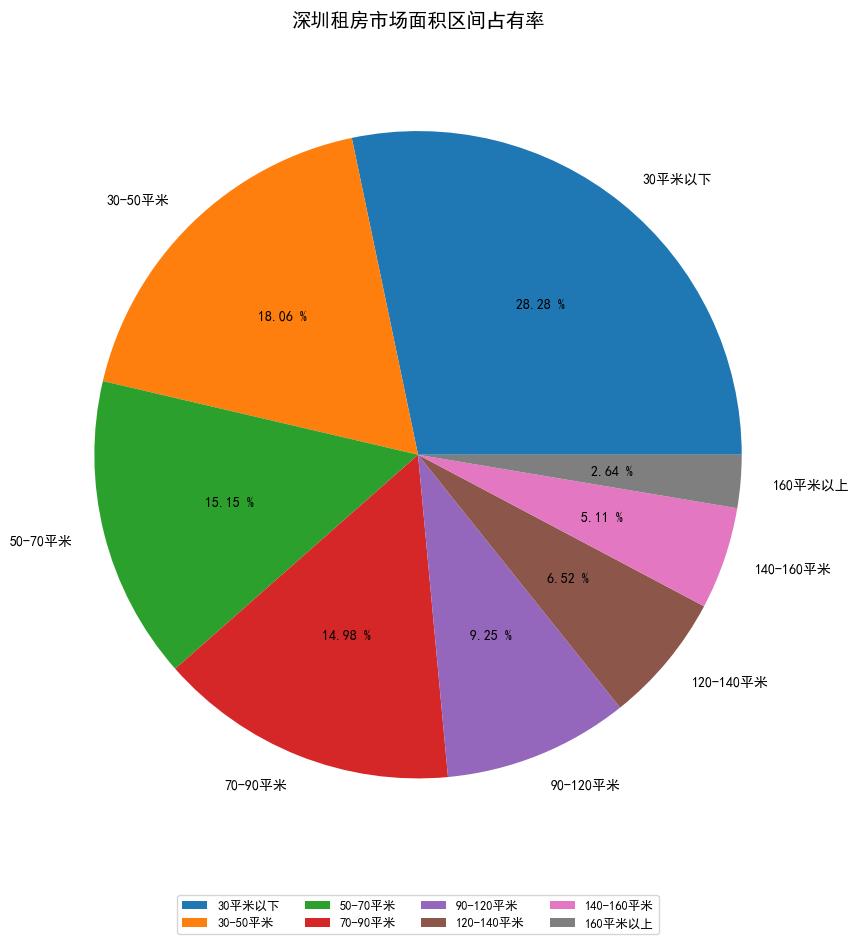

In [61]:
plt.figure(figsize=(10, 10))  # 调整尺寸为正方形，适配底部图例
plt.axes(aspect=1)

plt.pie(
    x=area_percentage, 
    labels=labels, 
    autopct='%.2f %%', 
    shadow=False
)

# 将图例移至饼图下方外部
plt.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.1),  # 图例在饼图下方中间位置
    ncol=4,  # 图例横向排列4列，减少垂直空间占用
    fontsize=9
)

plt.title('深圳租房市场面积区间占有率', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整布局，给底部图例预留空间
plt.show()

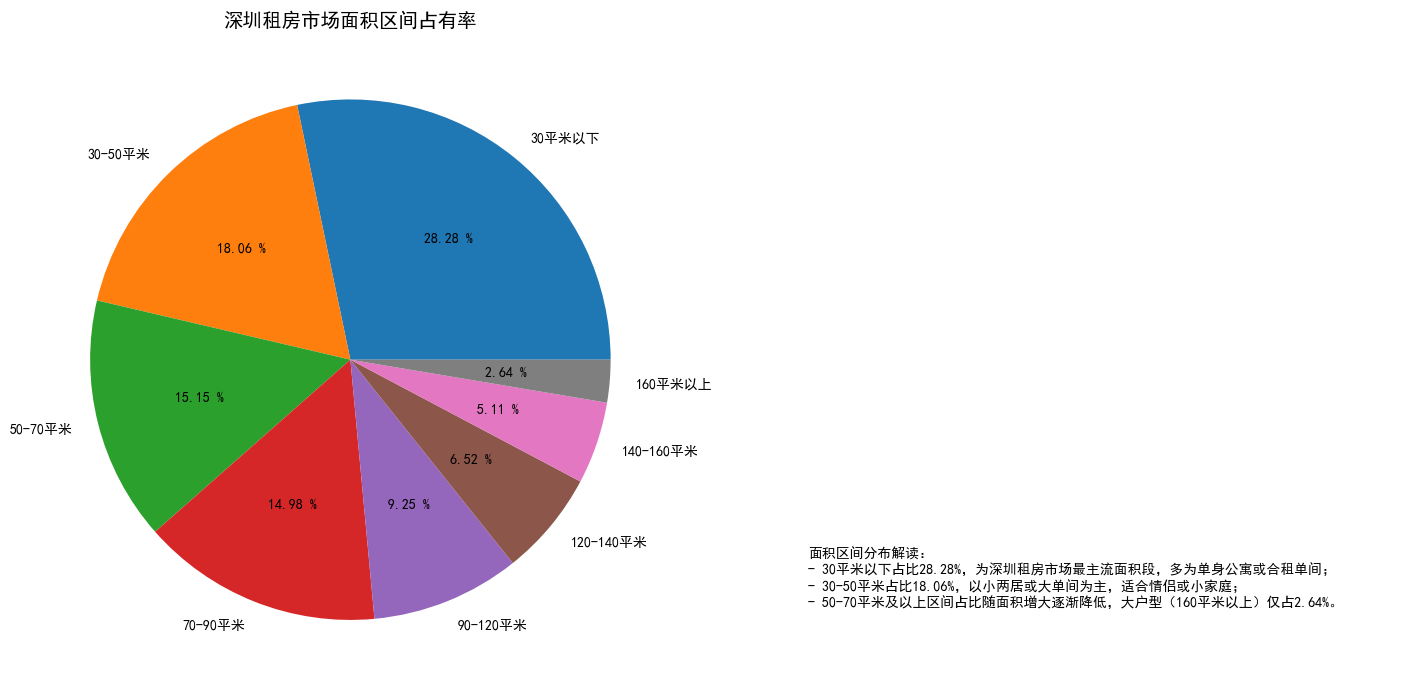

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))  # 左右分栏布局

# 左侧绘制饼图
ax1.set_aspect('equal')
ax1.pie(
    x=area_percentage, 
    labels=labels, 
    autopct='%.2f %%', 
    shadow=False
)
ax1.set_title('深圳租房市场面积区间占有率', fontsize=14)

# 右侧添加说明文本（示例）
text_content = """
面积区间分布解读：
- 30平米以下占比28.28%，为深圳租房市场最主流面积段，多为单身公寓或合租单间；
- 30-50平米占比18.06%，以小两居或大单间为主，适合情侣或小家庭；
- 50-70平米及以上区间占比随面积增大逐渐降低，大户型（160平米以上）仅占2.64%。
"""
ax2.text(0.1, 0.1, text_content, fontsize=10, wrap=True)
ax2.axis('off')  # 隐藏右侧子图的坐标轴

plt.tight_layout()
plt.show()

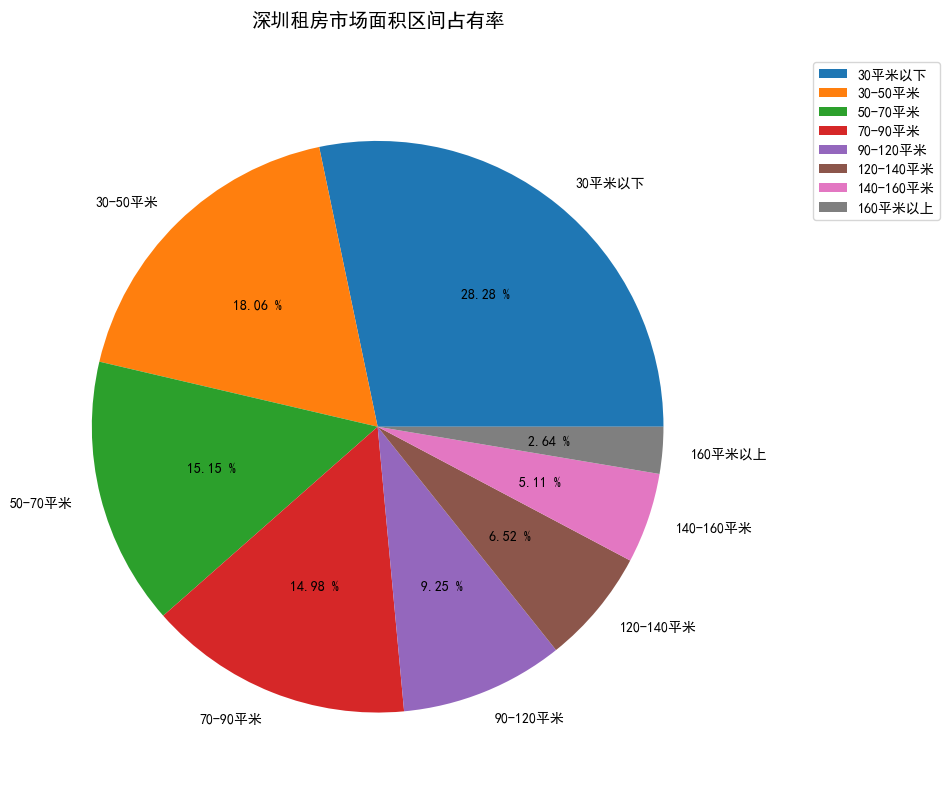

In [69]:
# 假设area_percentage和labels已按之前逻辑生成
plt.figure(figsize=(12, 8))  # 增大图表尺寸，预留图例空间
plt.axes(aspect=1)  # 保证饼图为圆形

plt.pie(
    x=area_percentage, 
    labels=labels, 
    autopct='%.2f %%', 
    shadow=False  # 去掉阴影，使图表更简洁
)

# 将图例移至饼图右侧外部，避免重叠
plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.1, 0.9),  # 图例在饼图右侧中间位置
    fontsize=10
)

plt.title('深圳租房市场面积区间占有率', fontsize=14, y=1.05)  # 调整标题垂直位置，避免挤压
plt.tight_layout()  # 自动优化布局，确保元素不重叠
plt.show()

In [72]:
#模型构建与评估
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. 提取特征和目标变量
# 特征：区域（分类）、户型（分类）、面积（连续）、朝向（分类）
# 目标：月租金
X = file_data[['区域', '户型', '面积(㎡)', '朝向']]
y = file_data['价格(元/月)']

# 查看数据规模
print("特征数据形状：", X.shape)
print("目标变量形状：", y.shape)

特征数据形状： (1135, 4)
目标变量形状： (1135,)


In [73]:
#特征工程
# 2. 定义特征类型（分类特征需编码，连续特征直接使用）
categorical_features = ['区域', '户型', '朝向']  # 分类特征
numerical_features = ['面积(㎡)']  # 连续特征

# 3. 特征转换管道（自动处理分类特征的独热编码）
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),  # 连续特征不处理
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # 分类特征独热编码
    ])

In [74]:
# 4. 划分训练集和测试集（随机种子保证结果可复现）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("训练集规模：", X_train.shape)
print("测试集规模：", X_test.shape)

训练集规模： (908, 4)
测试集规模： (227, 4)


In [75]:
#1. 线性回归（基准模型）
from sklearn.linear_model import LinearRegression

# 构建包含预处理和模型的管道
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 训练模型
model_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['面积(㎡)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['区域', '户型', '朝向'])])),
                ('regressor', LinearRegression())])

In [76]:
#2. 随机森林回归（集成模型，通常效果更好）
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))  # 100棵树
])

model_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['面积(㎡)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['区域', '户型', '朝向'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [77]:
#评估代码
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 定义评估函数
def evaluate_model(model, X_test, y_test, model_name):
    # 预测测试集
    y_pred = model.predict(X_test)
    # 计算指标
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # 输出结果
    print(f"=== {model_name} 评估结果 ===")
    print(f"均方误差（MSE）：{mse:.2f}")
    print(f"均方根误差（RMSE）：{rmse:.2f} 元")  # 单位与租金一致，直观
    print(f"平均绝对误差（MAE）：{mae:.2f} 元")
    print(f"R²评分：{r2:.4f}")       #R² 评分	 模型解释目标变量变异的比例（0~1）	越接近 1，解释力越强	

# 评估线性回归
evaluate_model(model_lr, X_test, y_test, "线性回归")

# 评估随机森林
evaluate_model(model_rf, X_test, y_test, "随机森林回归")

=== 线性回归 评估结果 ===
均方误差（MSE）：14555031.23
均方根误差（RMSE）：3815.11 元
平均绝对误差（MAE）：2144.66 元
R²评分：0.6682
=== 随机森林回归 评估结果 ===
均方误差（MSE）：10640090.88
均方根误差（RMSE）：3261.92 元
平均绝对误差（MAE）：1772.84 元
R²评分：0.7574
